In [1]:
from datascience import * 
import matplotlib
import numpy as np
import matplotlib.pyplot as plots
path_data = '../../data/data8/'
matplotlib.use('Agg')
%matplotlib inline
plots.style.use('fivethirtyeight')

In [2]:
top1 = Table.read_table(path_data + 'top_movies_2017.csv')
top2 = top1.with_column('Row Index', np.arange(top1.num_rows))
top = top2.move_to_start('Row Index')

top.set_format(make_array(3, 4), NumberFormatter)

Row Index,Title,Studio,Gross,Gross (Adjusted),Year
0,Gone with the Wind,MGM,"198,676,459","1,796,176,700",1939
1,Star Wars,Fox,"460,998,007","1,583,483,200",1977
2,The Sound of Music,Fox,"158,671,368","1,266,072,700",1965
3,E.T.: The Extra-Terrestrial,Universal,"435,110,554","1,261,085,000",1982
4,Titanic,Paramount,"658,672,302","1,204,368,000",1997
5,The Ten Commandments,Paramount,"65,500,000","1,164,590,000",1956
6,Jaws,Universal,"260,000,000","1,138,620,700",1975
7,Doctor Zhivago,MGM,"111,721,910","1,103,564,200",1965
8,The Exorcist,Warner Brothers,"232,906,145","983,226,600",1973
9,Snow White and the Seven Dwarves,Disney,"184,925,486","969,010,000",1937


## Taking Samples
### Deterministic samples
When you specify which elements you want to choose without any chances involved, you ceate a _determinstic_ sample.

In [10]:
# using take
top.take(make_array(3, 8, 34))

Row Index,Title,Studio,Gross,Gross (Adjusted),Year
3,E.T.: The Extra-Terrestrial,Universal,"435,110,554","1,261,085,000",1982
8,The Exorcist,Warner Brothers,"232,906,145","983,226,600",1973
34,Shrek 2,Dreamworks,"441,226,247","631,642,700",2004


In [11]:
# using where
top.where("Title", are.containing("Harry Potter"))

Row Index,Title,Studio,Gross,Gross (Adjusted),Year
74,Harry Potter and the Sorcerer's Stone,Warner Brothers,"317,575,550","497,066,400",2001
114,Harry Potter and the Deathly Hallows Part 2,Warner Brothers,"381,011,219","426,630,300",2011
131,Harry Potter and the Goblet of Fire,Warner Brothers,"290,013,036","401,608,200",2005
133,Harry Potter and the Chamber of Secrets,Warner Brothers,"261,988,482","399,302,200",2002
154,Harry Potter and the Order of the Phoenix,Warner Brothers,"292,004,738","377,314,200",2007
175,Harry Potter and the Half-Blood Prince,Warner Brothers,"301,959,197","359,788,300",2009
177,Harry Potter and the Prisoner of Azkaban,Warner Brothers,"249,541,069","357,233,500",2004


These are not random samples because they were specifically chosen

### Probability Samples

For describing random samples, some terminology will be helpful.

A _population_ is the set of all elements from whom a sample will be drawn.

A _probability sample_ is one for which it is possible to calculate, before the sample is drawn, the chance with which any subset of elements will enter the sample.

In a probability sample, all elements need not have the same chance of being chosen.

## A Systematic Sample

Imagine all the elements of the population listed in a sequence. One method of sampling starts by choosing a random position early in the list, and then evenly spaced positions after that. The sample consists of the elements in those positions. Such a sample is called a _systematic sample_.

Here we will choose a systematic sample of the rows of _top_. We will start by picking one of the first 10 rows at random, and then we will pick every 10th row after that.

In [13]:
"""Choose a random start among rows 0 through 9;
then take every 10th row."""

start = np.random.choice(np.arange(10))
top.take(np.arange(start, top.num_rows, 10))

Row Index,Title,Studio,Gross,Gross (Adjusted),Year
2,The Sound of Music,Fox,"158,671,368","1,266,072,700",1965
12,The Empire Strikes Back,Fox,"290,475,067","872,825,900",1980
22,Fantasia,Disney,"76,408,097","738,256,500",1941
32,Sleeping Beauty,Disney,"51,600,000","646,090,100",1959
42,Beverly Hills Cop,Paramount,"234,760,478","596,963,700",1984
52,The Bells of St. Mary's,RKO,"21,333,333","557,803,900",1945
62,The Passion of the Christ,NM,"370,782,930","530,776,000",2004
72,Finding Dory,Buena Vista,"486,295,561","499,245,400",2016
82,The Lord of the Rings: The Fellowship of the Ring,Newline,"315,544,750","487,165,600",2001
92,Avengers: Age of Ultron,Buena Vista,"459,005,868","475,854,300",2015


This systematic sample is also a probability sample because the first choice is random and determines the others.

## Random Samples Drawn With or Without Replacement

In this course, we will mostly deal with the two most straightforward methods of sampling.

The first is random sampling with replacement, which (as we have seen earlier) is the default behavior of `np.random.choice` when it samples from an array.

The other, called a “simple random sample”, is a sample drawn at random _without_ replacement. Sampled individuals are not replaced in the population before the next individual is drawn. This is the kind of sampling that happens when you deal a hand from a deck of cards, for example. To use `np.random.choice` for simple random sampling, you must include the argument `replace=False`.

In this chapter, we will use simulation to study the behavior of large samples drawn at random with or without replacement.

## Convenience Samples
Drawing a random sample requires care and precision. It is not haphazard even though that is a colloquial meaning of the word "random".

If you stand at a street corner and take as your sample the first ten people who pass by, you might think you're sampling at random because you didn't choose who walked by. But it's not a random sample – it's a *sample of convenience*. 

You didn't know ahead of time the probability of each person entering the sample; perhaps you hadn't even specified exactly who was in the population.

In data science, the word “empirical” means “observed”. 
**Empirical distributions** are distributions of observed data, such as data in random samples.

In this section we will generate data and see what the empirical distribution looks like.

Our setting is a simple experiment: rolling a die multiple times and keeping track of which face appears. The table `die` contains the numbers of spots on the faces of a die. All the numbers appear exactly once, as we are assuming that the die is fair.

In [2]:
die = Table().with_column('Face', np.arange(1, 7, 1))
die

Face
1
2
3
4
5
6


## 1. A Probability Distribution
The histogram below helps us visualize the fact that every face appears with probability 1/6. 

We say that the histogram shows the _distribution of probabilities_ over all the possible faces. 

Since all the bars represent the same percent chance, the distribution is called _uniform on the integers 1 through 6_.

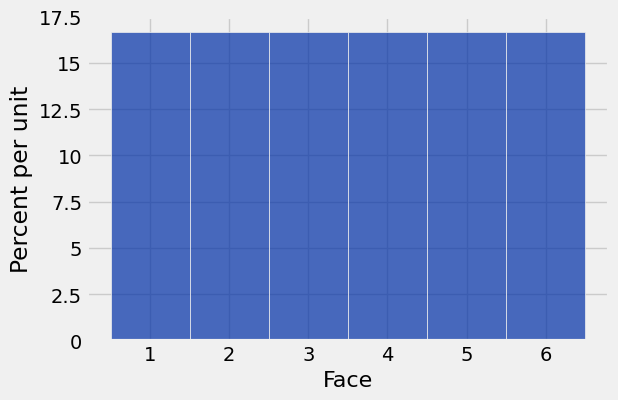

In [4]:
# Uniform distribution
die_bins = np.arange(0.5, 6.6, 1)
die.hist(bins = die_bins)

## 2. Empirical Distributions
The distribution above consists of the _theoretical probability_ of each face. It is called a _probability distribution_ and is not based on observed data. It can be studied and understood without any dice being rolled.

Empirical distributions, on the other hand, are distributions of observed data. They can be visualized by _empirical histograms_.

In [6]:
# with the Table method `sample` we can simulate a random
# sampling on the rows of the table.

die.sample(10)
# This gives you the result of rolling the die 10 times.


Face
1
4
4
3
3
1
6
4
4
2


In [7]:
# Let's do it `n` times using a function

def empirical_hist_die(n):
    die.sample(n).hist(bins = die_bins)

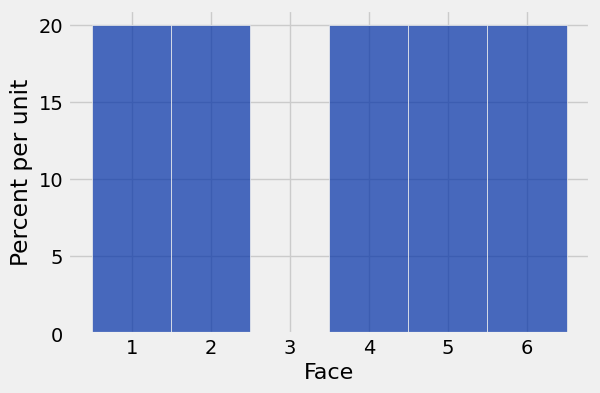

In [8]:
empirical_hist_die(10)

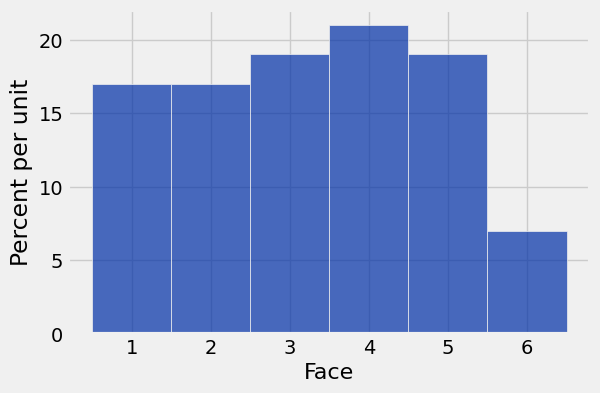

In [9]:
empirical_hist_die(100)

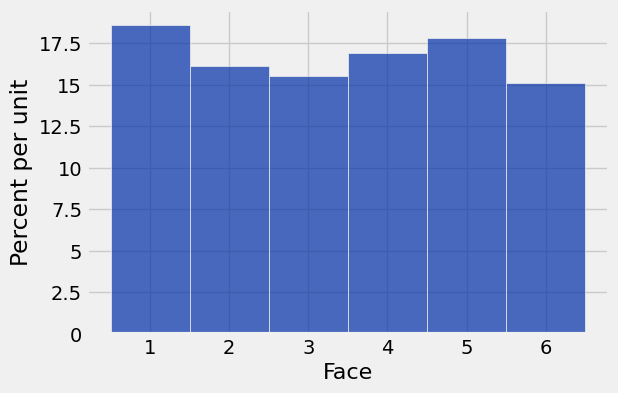

In [10]:
empirical_hist_die(1000)

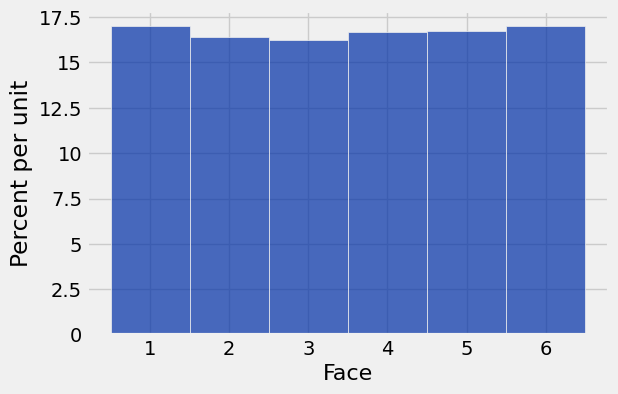

In [11]:
empirical_hist_die(10000)

As we increase the number of rolls in the simulation, the area of each bar gets closer to 16.67%, which is the area of each bar in the probability histogram.

## The Law of Averages
What we have observed above is an instance of a general rule called the _law of averages_.

Under these conditions, the law above implies that if the chance experiment is repeated a large number of times then the proportion of times that an event occurs is very likely to be close to the theoretical probability of the event.